# Introduction

The objective of this program is to detect and classify brain tumours to aid radiologists in the identification of tumour types

# Research and Data Exploration

## Research

Chosen paper: [A deep learning approach for brain tumor classification using MRI images](https://www.sciencedirect.com/science/article/pii/S0045790622003603?casa_token=drskL0VW6mUAAAAA:8Ywrm0JE-jLn5IUvmJxB2VMGom9AS2yOdun4bYpz0SqHQHnEGNGzdhtEt9GM8Etvej8ZPL2bJeuJ)

(Downloaded: 16/10/2025)


### Methods

The paper focuses on creating a model that can accurately detect and classify brain tumours from MRI images. The main methods used are improvement of image quality, extracting of strong features, finding where the tumour is located and identifying what type of tumour it is.

This is done using two pre-trained CNNs. Those are: EfficientNet-B0 and ResNet50

Image Enhancement techniques are also utilised such as Illumination Boosting and Non-Linear Stretching.

Illumination boosting uses logarithmic scaling + exponential transform + a modified cumulative distribution function to improve global contrast and brightness.

Non-Linear stretching enhances textural detail by adjusting pixel intensity distribution by a controlled stretching function


### Results

The model produced an overall classification accuracy of 98.95%, which it correctly predicted 3009 out of 3064 cases.

The model performed extremely well across all tumour types with accuracy being Meningioma at 98.3%, Glioma at 98.72% and Pituitary at 99.37%.

The model required no manual segmentation, making it simpler and faster than a lot of existing approaches.

In the paper a comparison is made between earlier studies using the same dataset. This comparison showed the model used achieved the highest accuracy that was reported. This surpassed other CNN, CapsNet and SVM based systems.

The results in the paper show that the proposed method is highly accurate, stable and effective at automatically classifying brain tumours from MRI images. Due to its strong performance, it could be very useful to radiologists as a support for their decision making.



### Limitations

The main limitations mentioned in the paper is that the model works best when there is a lot of training data. Therefore, performance may drop with smaller datasets. However, training on large datasets can lead to it becoming slow and more expensive.

It is also mentioned that tumour localisation could be improved with more advanced learning methods. Another mention is that the model could be expanded to handle more datatypes.

Even though the results are strong the room for improvement in efficiency and scalability are acknowledged.

### Choice Justification

I chose this paper as it's relevant to the work I am doing in this coursework. The paper also uses a public dataset which allows for others to replicate the study themselves allowing for whatever they have in the paper to be easily scrutinised by academic peers.

This paper was also published in a peer reviewed journal called "Computers and Electrical Engineering" in volume 101. The journal is also relatively high ranking.


## Data Exploration / Preperation

The [dataset](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri/data) was chosen as it is licensed by MIT. It has also been utilised by multiple others in similar types of projects, however there are no official publications using the dataset that I can find.

The paper I referenced before used a similar dataset. The dataset chosen seems to be made from the same source as the research paper. However I am unsure if any major or minor changes have been made.

### Imports

In [1]:
#Importing required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from matplotlib.image import imread
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model # Added Model here
from tensorflow.keras.layers import Activation, Dropout, AveragePooling2D,Flatten, Dense, Conv2D,MaxPool2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
from sklearn.utils import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
import random

In [2]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Check listed directories of dataset
main_dr_path = '/content/drive/MyDrive/Colab Notebooks/Coursework/Data/archive'
print(os.listdir(main_dr_path))

['Training', 'Testing']


In [4]:
# path for train / test folders
train_folder_path = main_dr_path + '/Training'
test_folder_path = main_dr_path + '/Testing'

In [5]:
# Defining the labels used for classification (e.g. no_tumor, pituitary_tumor etc. )
labels = os.listdir(train_folder_path)
print(labels)

['meningioma_tumor', 'no_tumor', 'pituitary_tumor', 'glioma_tumor']


In [6]:
#Variable declerations for later use
img_rows, img_cols = 112, 112
input_shape = img_rows,img_cols
batch_size = 16
n_epochs = 25
num_classes = len(labels)

In [7]:
#Assigning paths to tumour type folders
train_n_path = train_folder_path + '/no_tumor'
train_p_path = train_folder_path + '/pituitary_tumor'
train_g_path = train_folder_path + '/glioma_tumor'
train_m_path = train_folder_path + '/meningioma_tumor'

test_n_path = test_folder_path + '/no_tumor'
test_p_path = test_folder_path + '/pituitary_tumor'
test_g_path = test_folder_path + '/glioma_tumor'
test_m_path = test_folder_path + '/meningioma_tumor'

Defining Seeds for reproducible results

In [8]:
SEED = 250402

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

## Defining Functions

### Counting Images

In [9]:
def print_folder_image_counts(folder_path, labels):
    total_images = 0
    set_name = 'Training' if folder_path == train_folder_path else 'Testing'
    print(f'{set_name} Image Counts:')
    for label in labels:
        path = os.path.join(folder_path, label)
        if os.path.exists(path) and os.path.isdir(path):
            num_images = len(os.listdir(path))
            print(f'Number of {label.replace("_", " ")} images is {num_images}')
            total_images += num_images
        else:
            print(f'Warning: Path {path} does not exist or is not a directory.')

    print(f'Total {set_name.lower()} images is {total_images}\n')

### Getting Data

In [10]:
#Function to load images and extract labels according to the folder. Also setting images to same sizes
def get_train_data(data_dir):
  data = []
  for label in labels:
    path = os.path.join(data_dir, label)
    class_num = labels.index(label)
    for img_name in os.listdir(path):
      try:
        img_path = os.path.join(path, img_name)
        img_arr = cv2.imread(img_path, cv2.IMREAD_COLOR) # Changed to load color images
        if img_arr is not None:
          resized_arr = cv2.resize(img_arr, (input_shape))
          data.append([resized_arr, class_num])
          # print(f"Processed image: {img_name}, shape: {resized_arr.shape}") # Uncomment for debugging
        else:
          print(f"Warning: Could not read image {img_path}")
      except Exception as e:
        print(f"Error processing image {img_name}: {e}")
  return np.array(data, dtype=object) # Use dtype=object to allow for potentially irregular shapes initially

### Accuracy and Loss Evaluation

In [11]:
def evaluate_model(model, X_test_eval, y_test_eval):
    print("\nEvaluating on Test Data:")
    test_loss, test_acc = model.evaluate(X_test_eval, y_test_eval, verbose=2)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc*100:.2f}%")

### Accuracy and Loss Graphs

In [12]:
# Accuracy and Loss Curves
def plot_accuracy_and_loss(history):
    plt.figure(figsize=(15, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### Prediction

In [13]:
def pred(model=None):
    predictions = model.predict(x_test)
    predicted_class = np.argmax(predictions, axis=1)
    class_labels = np.array(labels)
    return predicted_class, class_labels

### Confusion Matrix

In [14]:
from sklearn.metrics import confusion_matrix
def plot_conf_matrix(true_class = None, predicted_class = None):
    conf_matrix = confusion_matrix(true_class, predicted_class)
    #print(f"CNN_model Confusion Matrix:\n", conf_matrix)
    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.title("Confusion Matrix", fontsize=14)
    plt.show()

### Classification Report

In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
def classification_R(model_name = None, true_class = None, predicted_class = None):
    # Model performance metrics
    accuracy = accuracy_score(true_class, predicted_class)
    precision, recall, f1_score, _ = precision_recall_fscore_support(true_class, predicted_class, average='weighted')
    # Display the evaluation metrics
    print(f"{model_name} model Accuracy: {accuracy:.4f}")
    print(f"{model_name} model Precision: {precision:.4f}")
    print(f"{model_name} model Recall: {recall:.4f}")
    print(f"{model_name} model F1-score: {f1_score:.4f}\n\n")

    class_report = classification_report(true_class, predicted_class, target_names=class_labels)
    print(f"{model_name} model Classification Report:\n", class_report)

### Visualising Images

In [16]:
# Function to show a number of images of each of the tumour types
def show_sample_images(number, dataset_path, labels):
    plt.figure(figsize=(15, 10))
    for i, label in enumerate(labels):
        label_path = os.path.join(dataset_path, label)
        images = os.listdir(label_path)
        for n in range(min(number, len(images))):
            img_name = images[n]
            img_path = os.path.join(label_path, img_name)
            img_load = Image.open(img_path).convert('L') # Convert to grayscale
            ax = plt.subplot(len(labels), number, i * number + n + 1)
            plt.imshow(img_load, cmap='gray')
            plt.title(label.replace('_', ' ').upper()) # Display label as title
            plt.axis("off")
    plt.tight_layout()
    plt.show()

## PreProcessing

In [17]:
# Call function for training set
print_folder_image_counts(train_folder_path, labels)

# Call function for testing set
print_folder_image_counts(test_folder_path, labels)

Training Image Counts:
Number of meningioma tumor images is 822
Number of no tumor images is 395
Number of pituitary tumor images is 827
Number of glioma tumor images is 826
Total training images is 2870

Testing Image Counts:
Number of meningioma tumor images is 115
Number of no tumor images is 105
Number of pituitary tumor images is 74
Number of glioma tumor images is 100
Total testing images is 394



### Validation Set Creation

In [18]:
train = get_train_data(train_folder_path)
temp = np.random.permutation(train) # Shuffle the data
train_size = 0.8 # Sets the split ratio

# Assigns 80% to training array and 20% to validation set
train, val = temp[:(int(train_size*len(temp)))], temp[int(train_size*len(temp)):]

In [19]:
#load test dataset
test = get_train_data(test_folder_path)

In [20]:
print(f'The shape of the training set is {train.shape}')
print(f'The shape of the test set is {test.shape}')
print(f'The shape of the val set is {val.shape}')

The shape of the training set is (2296, 2)
The shape of the test set is (394, 2)
The shape of the val set is (574, 2)


### Class Distribution

As seen in the graph and code below the classes are imbalanced. To combat this techniques such as data augmentation or class weights can be applied.

In [21]:
# Show class distribution
# Extract labels from the training dataset
train_labels = [label for _, label in train]

# Count the occurrences of each label
label_counts = pd.Series(train_labels).value_counts().sort_index()

# Map numerical labels to their string names for better readability
distribution = label_counts.rename(index=lambda x: labels[x])

print("Class Distribution in Training Set:")
print(distribution)

Class Distribution in Training Set:
meningioma_tumor    666
no_tumor            311
pituitary_tumor     658
glioma_tumor        661
Name: count, dtype: int64


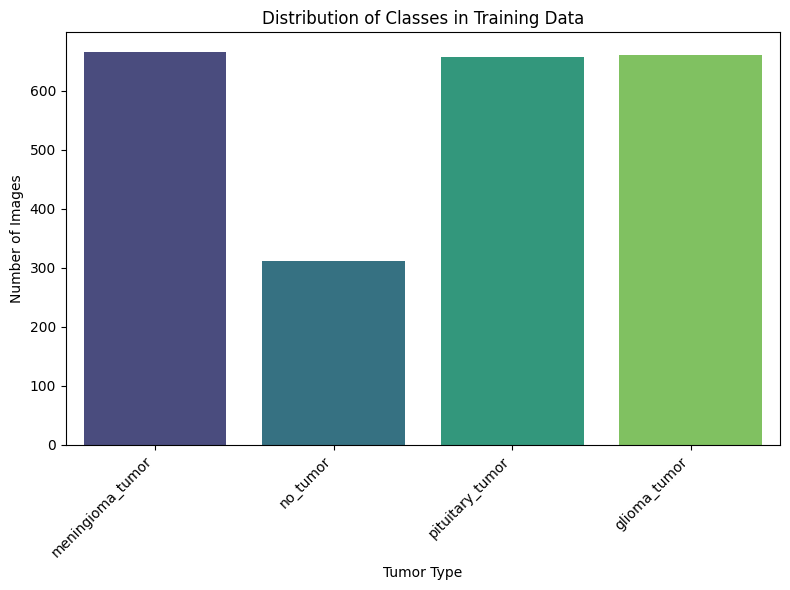

In [22]:
#View Class distribution visually
plt.figure(figsize=(8, 6))
sns.barplot(x=distribution.index, y=distribution.values, palette='viridis')
plt.title('Distribution of Classes in Training Data')
plt.xlabel('Tumor Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualising Images

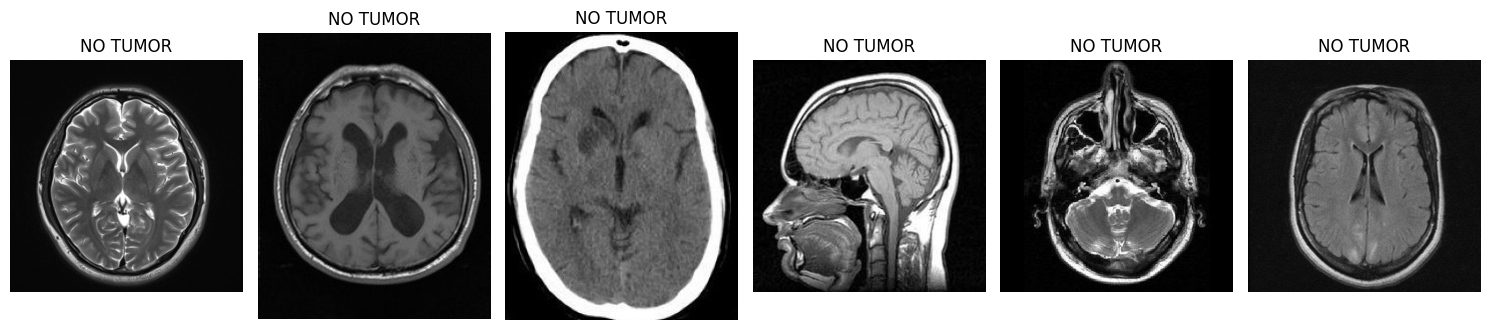

In [23]:
# Show 6 no_tumour images
show_sample_images(6, train_folder_path, ['no_tumor'])

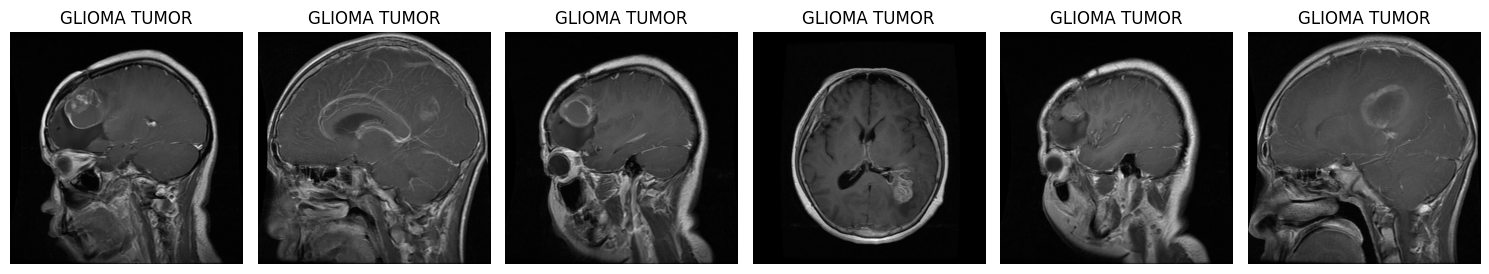

In [24]:
# Show 6 glioma_tumor images
show_sample_images(6, train_folder_path, ['glioma_tumor'])

X and Y assigning

In [25]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

In [26]:
print(f'Number of images in the training set is {len(x_train)}')

Number of images in the training set is 2296


### Data Standardisation

In [27]:
# Normalise the data

x_train = np.array(x_train) / 255.0
x_val = np.array(x_val) / 255.0
x_test = np.array(x_test) / 255.0

# Ensure labels are numpy arrays and convert to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

### Image Augmentation

Image augmentation is used here to help combat the imbalanced data. It does this by altering the existing data in random ways, in this case it rotates, zooms, shifts width and height.

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

datagen = ImageDataGenerator(
      featurewise_center=False,
      samplewise_center=False,
      featurewise_std_normalization=False,
      samplewise_std_normalization=False,
      zca_whitening=False,
      rotation_range = 30,  # Increased rotation range (previously 30)
      zoom_range = 0.2,     # Increased zoom range (previously 0.2)

      width_shift_range = 0.1, # Increased width shift (previously 0.1)
      height_shift_range = 0.1, # Increased height shift (previously 0.1)
      horizontal_flip = False, #Changed from True as not good for MRIs
      vertical_flip=False)

datagen.fit(x_train)

train_generator = datagen.flow(x_train, y_train, batch_size = batch_size, seed=SEED)

### Class Weights

Class weights like image augmentation is another way to combat class imbalance. It does this by assigning a number based on the imbalance e.g. lower amount of features would be a higher weigth value. This is then used by the model to ensure it doesn't always pick the label with the highest feature amount.

In [29]:
# Compute class weights using sklearn's utility function

# Convert one-hot encoded y_train back to integer labels for class weight calculation
y_train_labels = np.argmax(y_train, axis=1)

# Get unique classes from y_train_labels
classes = np.unique(y_train_labels)

# Calculate class weights
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_labels
)

# Convert to dictionary for model.fit()
class_weights_dict = dict(zip(classes, class_weights_values))

print(class_weights_dict)

{np.int64(0): np.float64(0.8618618618618619), np.int64(1): np.float64(1.8456591639871383), np.int64(2): np.float64(0.8723404255319149), np.int64(3): np.float64(0.8683812405446294)}


#Baseline Model

## CNN Model

This model was partially based off the Lab 5 from the course, however I simplified it greatly to show how a normal model would handle the task given. I think this is a good baseline as it shows a generic model.

The optimizer chosen was Adam as this [paper](https://arxiv.org/pdf/1412.6980) explains is a good choice to go with. It is also used in this [paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC10157370/#s2), which is similar to my task at hand.

In [30]:
CNN_model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(input_shape[0], input_shape[1], 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [31]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam()
CNN_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:
CNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 110, 110, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 110, 110, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 53, 53, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 53, 53, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,030,020 (7.74 MB)

 Trainable params: 2,029,060 (7.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [33]:
#Reduce Learning
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor = 0.5, patience = 3, min_lr = 1e-6, verbose = 1)

In [34]:
CNN_history = CNN_model.fit(train_generator,
                    epochs = n_epochs, validation_data = (x_val, y_val),
                    callbacks = [reduce_lr], class_weight = class_weights_dict)

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 29s 126ms/step - accuracy: 0.4021 - loss: 3.1923 - val_accuracy: 0.1446 - val_loss: 2.5344 - learning_rate: 0.0010
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.5118 - loss: 1.1666 - val_accuracy: 0.3328 - val_loss: 4.8200 - learning_rate: 0.0010
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.5663 - loss: 1.0659 - val_accuracy: 0.4739 - val_loss: 1.0787 - learning_rate: 0.0010
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.6018 - loss: 0.9494 - val_accuracy: 0.6150 - val_loss: 0.9159 - learning_rate: 0.0010
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.5826 - loss: 0.9230 - val_accuracy: 0.3728 - val_loss: 2.6667 - learning_rate: 0.0010
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.5983 - loss: 0.9486 - val_accuracy: 0.5192 - val_loss: 2.2617 - learning_rate: 0.0010
Epoch 7/25
143/144 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6604 - loss: 

### CNN Evaluation

In [35]:
evaluate_model(CNN_model, x_test, y_test)


Evaluating on Test Data:
13/13 - 1s - 77ms/step - accuracy: 0.5127 - loss: 4.0199
Test Loss: 4.0199, Test Accuracy: 51.27%


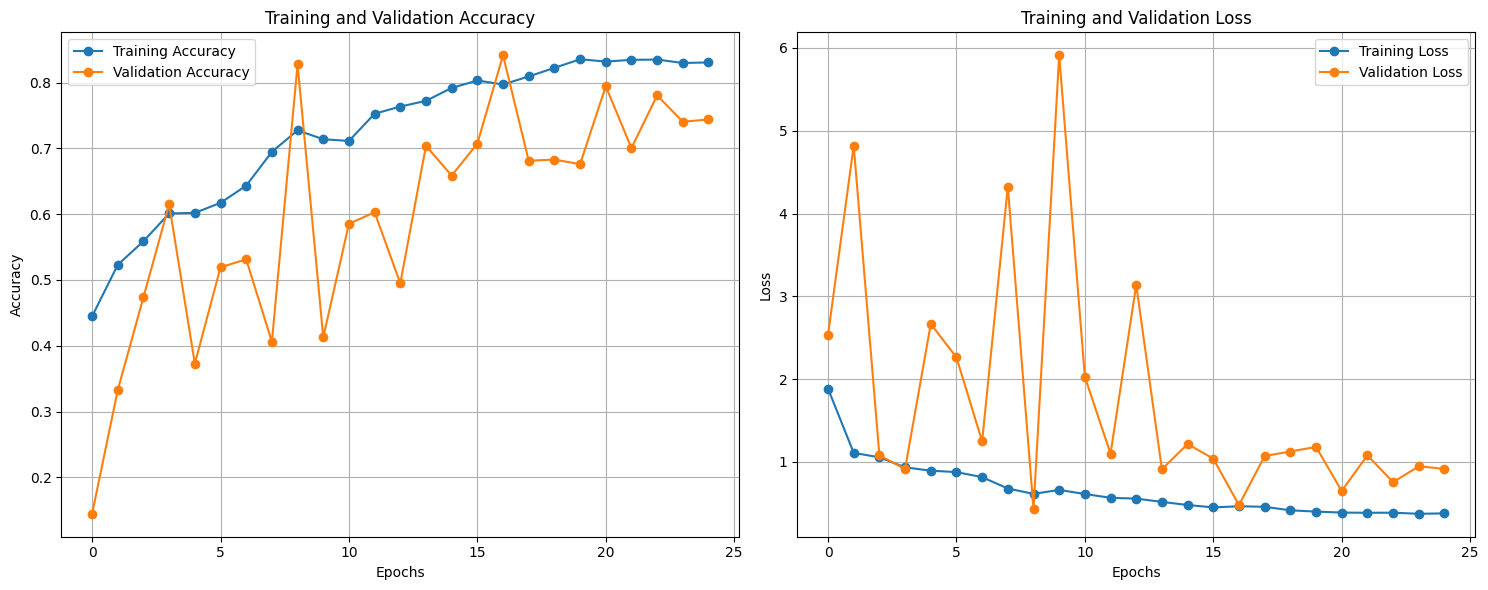

In [36]:
#Graph of Accuracy and loss
plot_accuracy_and_loss(CNN_history)

In [37]:
#Prediction
predicted_class, class_labels = pred(CNN_model)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step


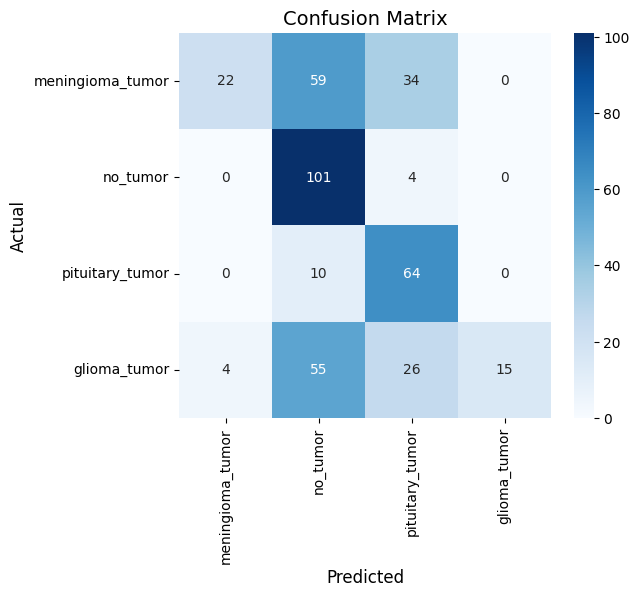

In [38]:
import numpy as np
#Confusion matrix
plot_conf_matrix(np.argmax(y_test, axis=1), predicted_class)

In [39]:
#Classification report
classification_R('CNN', np.argmax(y_test, axis=1), predicted_class)

CNN model Accuracy: 0.5127
CNN model Precision: 0.7143
CNN model Recall: 0.5127
CNN model F1-score: 0.4394


CNN model Classification Report:
                   precision    recall  f1-score   support

meningioma_tumor       0.85      0.19      0.31       115
        no_tumor       0.45      0.96      0.61       105
 pituitary_tumor       0.50      0.86      0.63        74
    glioma_tumor       1.00      0.15      0.26       100

        accuracy                           0.51       394
       macro avg       0.70      0.54      0.45       394
    weighted avg       0.71      0.51      0.44       394



#Solution Improvement

I used two different models to test deep transfer learnings improvement on the baseline model.

I chose the VGG19 and ResNet50 models as they were both recommended in this [paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC10157370/#s3) that is similar to the task I am doing with the minor difference of being binary and not categorical.

## VGG19 Model

In [40]:
from keras.applications.vgg19 import VGG19

In [41]:
#Loading VGG model and applying image size to input shape

vgg = VGG19(input_shape = (input_shape[0], input_shape[1], 3), include_top = False, weights = 'imagenet')

#Visualising the model
vgg.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
for  layer in vgg.layers:
    layer.trainable = False

In [43]:
#Build new model on top of VGG16
VGG_model = Sequential()
VGG_model.add(vgg)
VGG_model.add(Flatten())
VGG_model.add(Dense(512, activation='relu'))
VGG_model.add(Dropout(0.2))
VGG_model.add(Dense(512, activation='relu'))
VGG_model.add(Dropout(0.2))
VGG_model.add(Dense(512, activation='relu'))
VGG_model.add(Dropout(0.2))
VGG_model.add(Dense(512, activation='relu'))
VGG_model.add(Dropout(0.2))
VGG_model.add(Dense(4, activation='softmax'))

# Summary
VGG_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 3, 3, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,174,212 (88.40 MB)

 Trainable params: 3,149,828 (12.02 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [44]:
#Combining the model
VGG_model.compile( loss = 'categorical_crossentropy',
              optimizer = Adam(learning_rate=0.00005),
              metrics = ['accuracy'] )

In [45]:
VGG_history = VGG_model.fit(train_generator,
                    epochs = n_epochs, validation_data = (x_val, y_val),
                    callbacks = [reduce_lr], class_weight = class_weights_dict)

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 36s 188ms/step - accuracy: 0.2838 - loss: 1.3936 - val_accuracy: 0.6080 - val_loss: 1.0408 - learning_rate: 5.0000e-05
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.5202 - loss: 1.0821 - val_accuracy: 0.7038 - val_loss: 0.7690 - learning_rate: 5.0000e-05
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.6168 - loss: 0.8859 - val_accuracy: 0.7143 - val_loss: 0.6740 - learning_rate: 5.0000e-05
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.6512 - loss: 0.8044 - val_accuracy: 0.7700 - val_loss: 0.6078 - learning_rate: 5.0000e-05
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.6879 - loss: 0.7586 - val_accuracy: 0.7770 - val_loss: 0.5644 - learning_rate: 5.0000e-05
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.7043 - loss: 0.6970 - val_accuracy: 0.7753 - val_loss: 0.5579 - learning_rate: 5.0000e-05
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/st

### VGG19 Evaluation



In [46]:
evaluate_model(VGG_model, x_test, y_test)


Evaluating on Test Data:
13/13 - 3s - 232ms/step - accuracy: 0.5305 - loss: 1.9497
Test Loss: 1.9497, Test Accuracy: 53.05%


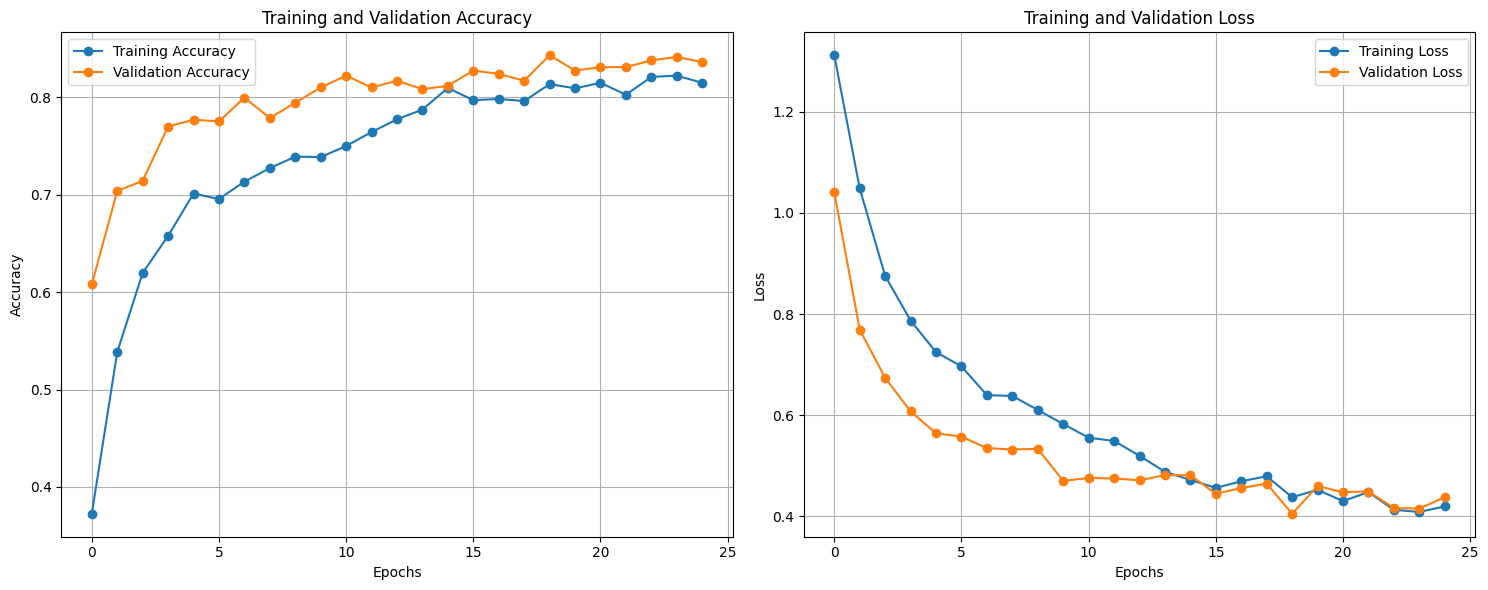

In [47]:
plot_accuracy_and_loss(VGG_history)

In [48]:
predicted_class, class_labels = pred(VGG_model)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step


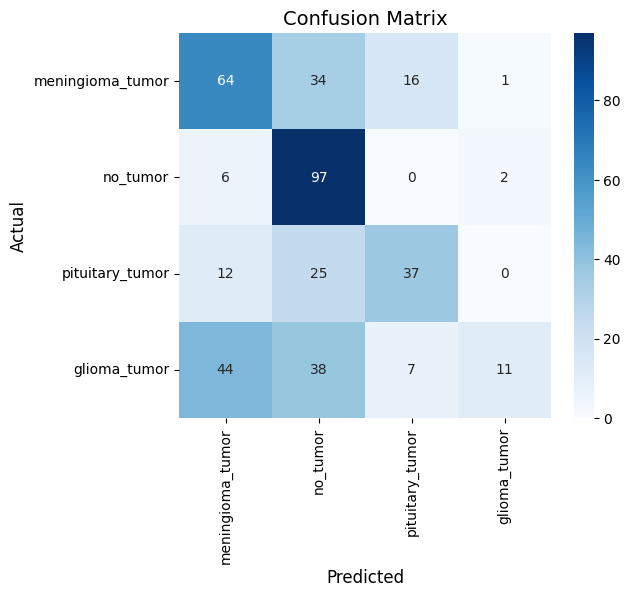

In [49]:
plot_conf_matrix(np.argmax(y_test, axis=1), predicted_class)

In [50]:
classification_R('VGG19', np.argmax(y_test, axis=1), predicted_class)

VGG19 model Accuracy: 0.5305
VGG19 model Precision: 0.5967
VGG19 model Recall: 0.5305
VGG19 model F1-score: 0.4806


VGG19 model Classification Report:
                   precision    recall  f1-score   support

meningioma_tumor       0.51      0.56      0.53       115
        no_tumor       0.50      0.92      0.65       105
 pituitary_tumor       0.62      0.50      0.55        74
    glioma_tumor       0.79      0.11      0.19       100

        accuracy                           0.53       394
       macro avg       0.60      0.52      0.48       394
    weighted avg       0.60      0.53      0.48       394



## ResNet50 Model

In [51]:
from tensorflow.keras.applications.resnet50 import ResNet50

#Loading VGG model and applying image size to input shape

rn50 = ResNet50(input_shape = (input_shape[0], input_shape[1], 3), include_top = False, weights = 'imagenet')

#Visualising the model
rn50.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 118, 118,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 56, 56,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 56, 56,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 56, 56,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 58, 58,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 28, 28,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 28, 28,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 28, 28,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 28, 28,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 28, 28,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 28, 28,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 28, 28,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 28, 28,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 28, 28,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 28, 28,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 28, 28,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [52]:
#Freeze the layers
for  layer in vgg.layers:
    layer.trainable = False

In [53]:
#Build new model on top of RN50
rn50_model = Sequential()
rn50_model.add(rn50)
rn50_model.add(Flatten())
rn50_model.add(Dense(512, activation='relu'))
rn50_model.add(Dropout(0.2))
rn50_model.add(Dense(512, activation='relu'))
rn50_model.add(Dropout(0.2))
rn50_model.add(Dense(512, activation='relu'))
rn50_model.add(Dropout(0.2))
rn50_model.add(Dense(512, activation='relu'))
rn50_model.add(Dropout(0.2))
rn50_model.add(Dense(4, activation='softmax'))

# Summary
rn50_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,155,460 (157.00 MB)

 Trainable params: 41,102,340 (156.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [54]:
#Combining the model
rn50_model.compile( loss = 'categorical_crossentropy',
              optimizer = Adam(learning_rate=0.00005),
              metrics = ['accuracy'] )

In [55]:
rn50_history = rn50_model.fit(train_generator,
                    epochs = n_epochs, validation_data = (x_val, y_val),
                    callbacks = [reduce_lr], class_weight = class_weights_dict)

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 125s 394ms/step - accuracy: 0.4564 - loss: 1.2281 - val_accuracy: 0.1463 - val_loss: 4.8786 - learning_rate: 5.0000e-05
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.7879 - loss: 0.5403 - val_accuracy: 0.1463 - val_loss: 6.1059 - learning_rate: 5.0000e-05
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.8675 - loss: 0.3864 - val_accuracy: 0.1411 - val_loss: 3.1256 - learning_rate: 5.0000e-05
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.8789 - loss: 0.2952 - val_accuracy: 0.1882 - val_loss: 2.3762 - learning_rate: 5.0000e-05
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.8790 - loss: 0.2918 - val_accuracy: 0.1516 - val_loss: 4.8941 - learning_rate: 5.0000e-05
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.9274 - loss: 0.2063 - val_accuracy: 0.2108 - val_loss: 3.7162 - learning_rate: 5.0000e-05
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/

### rn50 Evaluation

In [56]:
evaluate_model(rn50_model, x_test, y_test)


Evaluating on Test Data:
13/13 - 4s - 298ms/step - accuracy: 0.7843 - loss: 2.0067
Test Loss: 2.0067, Test Accuracy: 78.43%


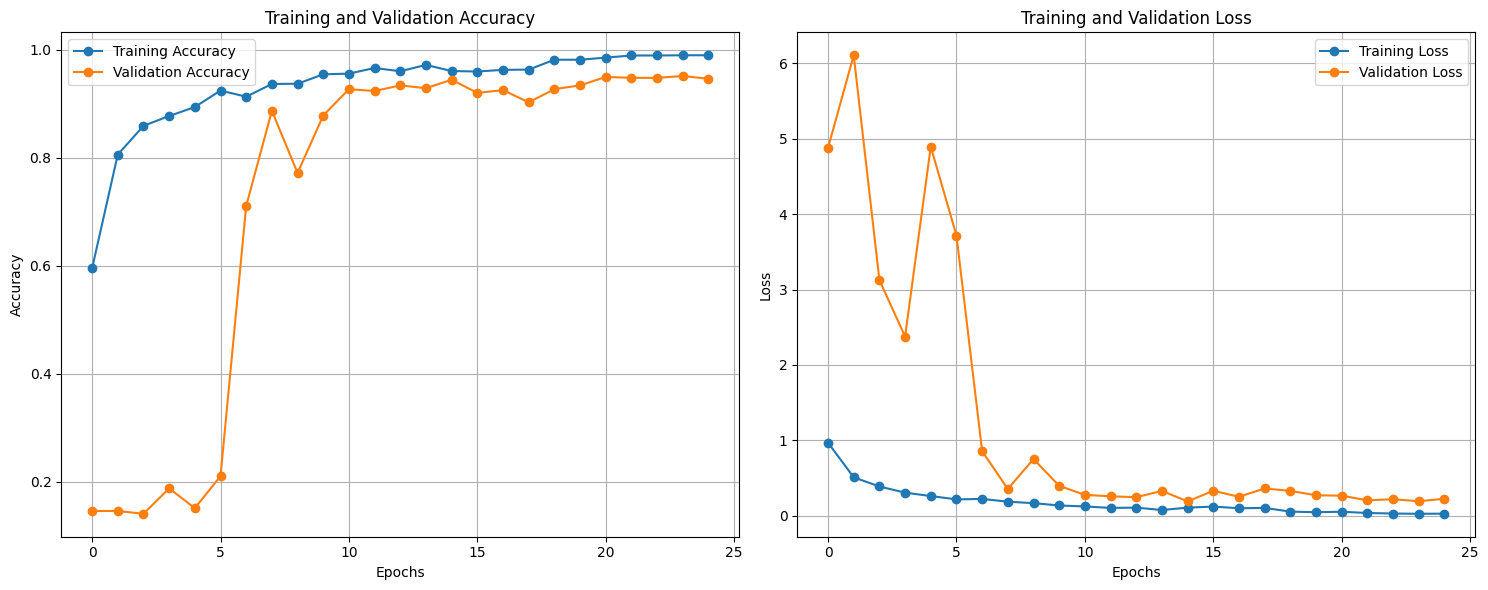

In [57]:
plot_accuracy_and_loss(rn50_history)

In [58]:
predicted_class, class_labels = pred(rn50_model)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step


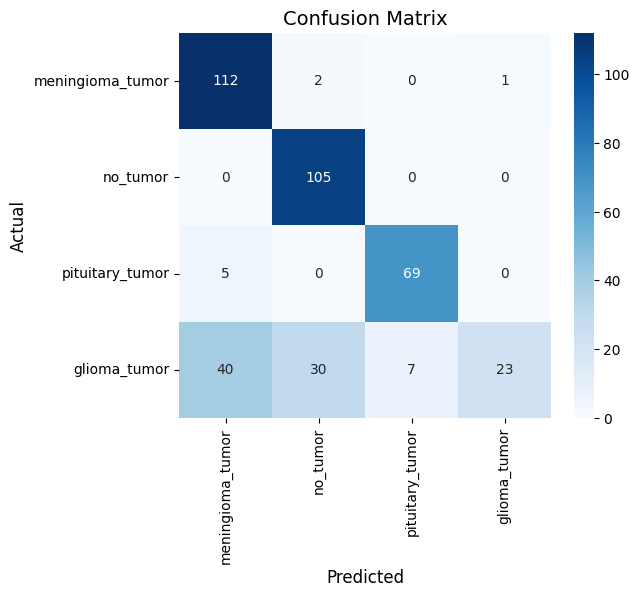

In [59]:
plot_conf_matrix(np.argmax(y_test, axis=1), predicted_class)

In [60]:
classification_R('ResNet50', np.argmax(y_test, axis=1), predicted_class)

ResNet50 model Accuracy: 0.7843
ResNet50 model Precision: 0.8262
ResNet50 model Recall: 0.7843
ResNet50 model F1-score: 0.7386


ResNet50 model Classification Report:
                   precision    recall  f1-score   support

meningioma_tumor       0.71      0.97      0.82       115
        no_tumor       0.77      1.00      0.87       105
 pituitary_tumor       0.91      0.93      0.92        74
    glioma_tumor       0.96      0.23      0.37       100

        accuracy                           0.78       394
       macro avg       0.84      0.78      0.75       394
    weighted avg       0.83      0.78      0.74       394



#Conclusion and Future Direction

The end results prove that as of the current program without improvements these models could not be used to accurately and safely predict tumour types from MRIs.

In order of performance on this particular seed would be the ResNet50 with higher scores in each precision, recall and f1. The VGG19 Model was second with the CNN model coming last. This outcome could change based on the seed given as the data augmentation could be preferred by any model if it were random.

The results are similar to the [paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC10157370/#s3) used to pick the improvement models. However, this could change due to different preprocessing techniques used or due to the seed used.

I think further data cleaning / preprocessing would be very beneficial and necessary for improvement. Some things like Illumination Boosting and Non-Linear Stretching as used in the paper from the research section could be particularly useful for increasing the accuracy of the models. Another improvemnt to possibly be made is fine tuning the models. By unfreezing other layers the model could potentially be improved.

A major limitation to this project is the hardware and training time. Training time / hardware was limited as I was only able to do so many runs of the program due to the free google colab GPU limit therefore kept the models to a training time that allowed me multiple runs to work on improvements.

Clean up

In [61]:
import os, signal
#os.kill(os.getpid(), signal.SIGKILL)